# EO4040 — Introducción a la Ciencia de Datos para Economía
## Sesión 2 — Calidad de datos y técnicas de limpieza

**Temas:** 1.2 Calidad de los datos | 1.3 Técnicas de limpieza  
**Objetivos:**
- Evaluar la calidad de un dataset identificando problemas comunes: valores faltantes, duplicados, tipos incorrectos, inconsistencias
- Aplicar técnicas de limpieza con Pandas para preparar datos para análisis
- Desarrollar un flujo de trabajo reproducible de preprocesamiento

**Dataset:** Encuesta Nacional de Ingresos y Gastos de los Hogares (ENIGH) — versión simplificada  
**Herramienta:** Python + Pandas

---

## Parte 0 — Setup

Verificamos que tenemos todo lo necesario para esta sesión.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('Todo listo para la sesión 2')

Pandas: 3.0.5
NumPy: 2.4.6
Todo listo para la sesión 2


---

## Parte 1 — ¿Qué es calidad de datos y por qué importa?

Antes de limpiar, necesitamos saber *qué* puede estar mal. En economía y política pública, los datos vienen de fuentes como:
- Encuestas (ENIGH, ENOE) → errores de captura, no respuesta, codificación inconsistente
- Registros administrativos (IMSS, SAT) → campos vacíos, cambios de formato entre años
- Datos abiertos de gobierno → metadatos faltantes, unidades mezcladas

Las dimensiones de calidad más comunes son:

| Dimensión | Pregunta clave | Ejemplo |
|---|---|---|
| **Completitud** | ¿Hay valores faltantes? | Ingreso = NaN en 20% de filas |
| **Consistencia** | ¿Los valores tienen sentido entre sí? | Edad = 5, nivel educativo = Licenciatura |
| **Exactitud** | ¿Los valores son correctos? | Ingreso mensual = 9999999 |
| **Unicidad** | ¿Hay registros duplicados? | Mismo hogar capturado dos veces |
| **Granularidad** | ¿El nivel de detalle es el adecuado? | Necesitamos municipio pero solo hay estado |
| **Temporalidad** | ¿Los datos son del período correcto? | Mezcla de datos de 2018 y 2022 |

---

## Parte 2 — Cargando datos con problemas reales

Vamos a crear un dataset sintético que replica los problemas comunes de la ENIGH. En la práctica real, ustedes descargarían esto desde:
- https://www.inegi.org.mx/programas/enigh/
- data.gob.mx

Este dataset tiene hogares mexicanos con variables de ingreso, características del jefe de hogar y acceso a servicios.

In [2]:
# Creamos un dataset con problemas realistas
np.random.seed(42)
n = 200

estados = ['Ciudad de México', 'Jalisco', 'Nuevo León', 'Oaxaca', 'Chiapas',
           'Veracruz', 'Guanajuato', 'Estado de México', 'CDMX', 'NL']  # ← inconsistencias

educacion_vals = ['Primaria', 'Secundaria', 'Preparatoria', 'Licenciatura',
                  'Posgrado', 'primaria', 'SECUNDARIA', 'Sin escolaridad', None]

data = {
    'folio_hogar': (
        list(range(1001, 1101)) +
        list(range(1001, 1051)) +  # duplicados
        list(range(1151, 1201))
    ),
    'estado': np.random.choice(estados, n),
    'num_integrantes': np.random.choice(
        [1,2,3,4,5,6,7,None,-1], n,  # ← valores imposibles
        p=[0.15,0.2,0.25,0.2,0.1,0.05,0.02,0.02,0.01]
    ),
    'ingreso_mensual': (
        np.random.lognormal(9.5, 0.8, n).tolist()
    ),
    'edad_jefe_hogar': np.random.choice(
        list(range(18, 85)) + [None, 999],  # ← código de no respuesta
        n
    ),
    'escolaridad_jefe': np.random.choice(educacion_vals, n),
    'acceso_internet': np.random.choice([1, 0, 'Si', 'No', None], n),  # ← tipos mezclados
    'gasto_alimentacion': np.random.lognormal(8, 0.6, n).tolist(),
    'vivienda_propia': np.random.choice(['Propia', 'Rentada', 'Prestada', None, 'propia'], n),
}

# Introducimos valores faltantes en ingreso (missing not at random — más frecuente en extremos)
ingreso_arr = np.array(data['ingreso_mensual'])
missing_idx = np.random.choice(n, size=25, replace=False)
ingreso_arr[missing_idx] = np.nan
data['ingreso_mensual'] = ingreso_arr.tolist()

# Creamos el DataFrame
df = pd.DataFrame(data)
print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(10)

Dataset cargado: 200 filas × 9 columnas


,folio_hogar,estado,num_integrantes,ingreso_mensual,edad_jefe_hogar,escolaridad_jefe,acceso_internet,gasto_alimentacion,vivienda_propia
0,1001,Guanajuato,3,19633.138999,63,Posgrado,Si,6990.466343,Rentada
1,1002,Oaxaca,5,19411.981125,51,Licenciatura,1,2116.570192,NaN
2,1003,Estado de México,4,33177.059425,66,Sin escolaridad,Si,1809.103425,Rentada
3,1004,Chiapas,2,NaN,62,primaria,0,3955.448735,propia
4,1005,Guanajuato,3,5345.664748,44,primaria,No,2140.224852,propia
5,1006,NL,4,21440.842145,43,Sin escolaridad,None,4357.958927,propia
6,1007,Nuevo León,5,6591.505629,64,SECUNDARIA,1,3366.920517,Propia
7,1008,Guanajuato,2,7634.994989,73,Sin escolaridad,None,1200.572171,NaN
8,1009,Estado de México,2,9558.565046,80,Secundaria,0,7543.964517,propia
9,1010,Chiapas,4,12220.436824,65,NaN,None,8756.281468,Propia


---

## Parte 3 — Diagnóstico de calidad: el primer paso siempre

Antes de tocar cualquier dato, necesitamos un **diagnóstico completo**. Un buen analista nunca modifica datos sin primero entender qué tiene.

In [3]:
# 3.1 Dimensiones y tipos
print('=== ESTRUCTURA DEL DATASET ===')
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print()
print('Tipos de datos:')
print(df.dtypes)

=== ESTRUCTURA DEL DATASET ===
Filas: 200
Columnas: 9

Tipos de datos:
folio_hogar             int64
estado                    str
num_integrantes        object
ingreso_mensual       float64
edad_jefe_hogar        object
escolaridad_jefe          str
acceso_internet        object
gasto_alimentacion    float64
vivienda_propia           str
dtype: object


In [4]:
# 3.2 Valores faltantes — cuántos y en qué proporción
print('=== VALORES FALTANTES ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Faltantes': missing,
    'Porcentaje (%)': missing_pct
}).sort_values('Porcentaje (%)', ascending=False)

print(missing_df[missing_df['Faltantes'] > 0])

=== VALORES FALTANTES ===
                  Faltantes  Porcentaje (%)
acceso_internet          42            21.0
vivienda_propia          39            19.5
ingreso_mensual          25            12.5
escolaridad_jefe         19             9.5
num_integrantes           6             3.0
edad_jefe_hogar           4             2.0


In [5]:
# 3.3 Duplicados
print('=== DUPLICADOS ===')
n_duplicados = df.duplicated(subset='folio_hogar').sum()
print(f'Registros con folio_hogar duplicado: {n_duplicados}')
print()
# Ver los duplicados
df[df.duplicated(subset='folio_hogar', keep=False)].sort_values('folio_hogar').head(8)

=== DUPLICADOS ===
Registros con folio_hogar duplicado: 50



,folio_hogar,estado,num_integrantes,ingreso_mensual,edad_jefe_hogar,escolaridad_jefe,acceso_internet,gasto_alimentacion,vivienda_propia
0,1001,Guanajuato,3,19633.138999,63,Posgrado,Si,6990.466343,Rentada
100,1001,Jalisco,2,42167.444209,23,Primaria,1,2837.586917,Rentada
101,1002,Ciudad de México,2,7620.825822,67,Sin escolaridad,Si,5827.698885,Prestada
1,1002,Oaxaca,5,19411.981125,51,Licenciatura,1,2116.570192,NaN
2,1003,Estado de México,4,33177.059425,66,Sin escolaridad,Si,1809.103425,Rentada
102,1003,Guanajuato,2,11912.855535,27,SECUNDARIA,0,3661.525738,Rentada
103,1004,Guanajuato,5,8262.779036,22,SECUNDARIA,Si,3920.803677,Rentada
3,1004,Chiapas,2,NaN,62,primaria,0,3955.448735,propia


In [6]:
# 3.4 Valores únicos en variables categóricas — detectamos inconsistencias
print('=== VALORES ÚNICOS EN CATEGÓRICAS ===')
categoricas = ['estado', 'escolaridad_jefe', 'acceso_internet', 'vivienda_propia']
for col in categoricas:
    print(f'\n--- {col} ---')
    print(df[col].value_counts(dropna=False))

=== VALORES ÚNICOS EN CATEGÓRICAS ===

--- estado ---
estado
Guanajuato          26
Estado de México    23
Ciudad de México    23
Chiapas             20
CDMX                20
NL                  19
Nuevo León          19
Oaxaca              18
Jalisco             17
Veracruz            15
Name: count, dtype: int64

--- escolaridad_jefe ---
escolaridad_jefe
SECUNDARIA         26
Primaria           25
primaria           24
Posgrado           23
Sin escolaridad    23
Secundaria         22
Preparatoria       20
NaN                19
Licenciatura       18
Name: count, dtype: int64

--- acceso_internet ---
acceso_internet
1       43
Si      42
0       42
None    42
No      31
Name: count, dtype: int64

--- vivienda_propia ---
vivienda_propia
propia      45
Propia      44
Rentada     40
NaN         39
Prestada    32
Name: count, dtype: int64


In [7]:
# 3.5 Estadísticas descriptivas — detectamos outliers y valores imposibles
print('=== ESTADÍSTICAS DESCRIPTIVAS (numéricas) ===')
df[['num_integrantes', 'ingreso_mensual', 'edad_jefe_hogar', 'gasto_alimentacion']].describe()

=== ESTADÍSTICAS DESCRIPTIVAS (numéricas) ===


,ingreso_mensual,gasto_alimentacion
count,175.000000,200.000000
mean,17346.212365,3913.713756
std,14549.192928,2295.589793
min,905.713996,696.224666
25%,6945.772344,2200.504783
50%,12566.305583,3372.444361
75%,21823.883213,4722.428333
max,74203.318397,13577.366474


### 🔍 Pausa de diagnóstico

Antes de continuar, documentemos todos los problemas encontrados:

| Variable | Problema encontrado | Evidencia |
|---|---|---|
| `folio_hogar` | Duplicados | ~50 folios repetidos |
| `estado` | Nombres inconsistentes | 'CDMX' = 'Ciudad de México', 'NL' = 'Nuevo León' |
| `num_integrantes` | Valores imposibles y faltantes | -1, None |
| `ingreso_mensual` | Valores faltantes (~12.5%) | NaN en 25 filas |
| `edad_jefe_hogar` | Código de no respuesta (999), faltantes | |
| `escolaridad_jefe` | Capitalización inconsistente, nulos | 'primaria' vs 'Primaria' vs 'SECUNDARIA' |
| `acceso_internet` | Tipos mezclados | 1/0 mezclado con 'Si'/'No' |
| `vivienda_propia` | Capitalización inconsistente | 'propia' vs 'Propia' |

---

## Parte 4 — Técnicas de limpieza

### 4.1 Duplicados: eliminar registros repetidos

In [8]:
# Siempre trabajamos sobre una COPIA — nunca modifiques el raw
df_clean = df.copy()

print(f'Filas antes: {len(df_clean)}')
df_clean = df_clean.drop_duplicates(subset='folio_hogar', keep='first')
print(f'Filas después de eliminar duplicados: {len(df_clean)}')

Filas antes: 200
Filas después de eliminar duplicados: 150


### 4.2 Estandarización de categóricas

La inconsistencia de texto es uno de los problemas más frecuentes en datos de encuestas.

In [9]:
# Estandarizamos 'estado' — unificamos abreviaturas y mayúsculas
mapa_estados = {
    'CDMX': 'Ciudad de México',
    'NL': 'Nuevo León'
}
df_clean['estado'] = df_clean['estado'].replace(mapa_estados)
print('Estados únicos después de limpiar:')
print(sorted(df_clean['estado'].dropna().unique()))

Estados únicos después de limpiar:
['Chiapas', 'Ciudad de México', 'Estado de México', 'Guanajuato', 'Jalisco', 'Nuevo León', 'Oaxaca', 'Veracruz']


In [10]:
# Estandarizamos 'escolaridad_jefe' — title case para todo
df_clean['escolaridad_jefe'] = (
    df_clean['escolaridad_jefe']
    .str.strip()
    .str.title()
)
print('Escolaridades únicas después de limpiar:')
print(df_clean['escolaridad_jefe'].value_counts(dropna=False))

Escolaridades únicas después de limpiar:
escolaridad_jefe
Primaria           41
Secundaria         31
Posgrado           18
NaN                17
Sin Escolaridad    16
Licenciatura       15
Preparatoria       12
Name: count, dtype: int64


In [11]:
# Estandarizamos 'vivienda_propia'
df_clean['vivienda_propia'] = df_clean['vivienda_propia'].str.strip().str.title()
print(df_clean['vivienda_propia'].value_counts(dropna=False))

vivienda_propia
Propia      64
NaN         33
Rentada     28
Prestada    25
Name: count, dtype: int64


In [12]:
# Estandarizamos 'acceso_internet' — convertimos todo a 0/1
def normalizar_binario(val):
    if val in [1, '1', 'Si', 'si', 'SI', 'Yes', 'yes']:
        return 1
    elif val in [0, '0', 'No', 'no', 'NO']:
        return 0
    else:
        return np.nan

df_clean['acceso_internet'] = df_clean['acceso_internet'].apply(normalizar_binario)
print('Valores únicos en acceso_internet:')
print(df_clean['acceso_internet'].value_counts(dropna=False))

Valores únicos en acceso_internet:
acceso_internet
1.0    67
0.0    52
NaN    31
Name: count, dtype: int64


### 4.3 Manejo de valores imposibles

In [13]:
# num_integrantes: -1 es imposible, reemplazamos con NaN
df_clean['num_integrantes'] = pd.to_numeric(df_clean['num_integrantes'], errors='coerce')
df_clean.loc[df_clean['num_integrantes'] < 0, 'num_integrantes'] = np.nan

# edad_jefe_hogar: 999 es código de no respuesta del INEGI
df_clean['edad_jefe_hogar'] = pd.to_numeric(df_clean['edad_jefe_hogar'], errors='coerce')
df_clean.loc[df_clean['edad_jefe_hogar'] == 999, 'edad_jefe_hogar'] = np.nan

print('Estadísticas después de limpiar valores imposibles:')
df_clean[['num_integrantes', 'edad_jefe_hogar']].describe()

Estadísticas después de limpiar valores imposibles:


,num_integrantes,edad_jefe_hogar
count,142.000000,146.000000
mean,3.253521,50.541096
std,1.480064,19.565673
min,1.000000,18.000000
25%,2.000000,34.000000
50%,3.000000,50.000000
75%,4.000000,68.000000
max,7.000000,84.000000


### 4.4 Imputación de valores faltantes

Para los NaN, hay varias estrategias. La elección depende del contexto econométrico:

In [14]:
# Estrategia 1: Eliminar filas con faltantes en variable clave
# Útil cuando el % de faltantes es pequeño y no hay sesgo de selección
df_sin_na_ingreso = df_clean.dropna(subset=['ingreso_mensual'])
print(f'Filas eliminando NaN en ingreso: {len(df_sin_na_ingreso)} (perdemos {len(df_clean)-len(df_sin_na_ingreso)} obs)')

# Estrategia 2: Imputar con la mediana (más robusta que la media para ingresos)
mediana_ingreso = df_clean['ingreso_mensual'].median()
df_clean['ingreso_mensual_imp'] = df_clean['ingreso_mensual'].fillna(mediana_ingreso)
print(f'\nMediana de ingreso usada para imputar: ${mediana_ingreso:,.0f}')

# Estrategia 3: Indicador de faltante (para usarlo como variable en modelos)
df_clean['ingreso_faltante'] = df_clean['ingreso_mensual'].isnull().astype(int)
print(f'Indicador creado: {df_clean["ingreso_faltante"].sum()} observaciones con ingreso faltante')

Filas eliminando NaN en ingreso: 130 (perdemos 20 obs)

Mediana de ingreso usada para imputar: $13,907
Indicador creado: 20 observaciones con ingreso faltante


In [15]:
# Para variables categóricas: imputamos con la moda o una categoría especial
df_clean['escolaridad_jefe'] = df_clean['escolaridad_jefe'].fillna('No Especificado')
df_clean['vivienda_propia'] = df_clean['vivienda_propia'].fillna('No Especificado')
df_clean['estado'] = df_clean['estado'].fillna('No Especificado')

print('Faltantes por columna después de imputar categóricas:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Faltantes por columna después de imputar categóricas:
num_integrantes     8
ingreso_mensual    20
edad_jefe_hogar     4
acceso_internet    31
dtype: int64


### 4.5 Tipos de datos correctos

In [16]:
# Convertir a tipos adecuados
df_clean['escolaridad_jefe'] = df_clean['escolaridad_jefe'].astype('category')
df_clean['vivienda_propia'] = df_clean['vivienda_propia'].astype('category')
df_clean['estado'] = df_clean['estado'].astype('category')
df_clean['acceso_internet'] = df_clean['acceso_internet'].astype('Int64')  # Int64 acepta NaN

print('Tipos de datos finales:')
print(df_clean.dtypes)

Tipos de datos finales:
folio_hogar               int64
estado                 category
num_integrantes         float64
ingreso_mensual         float64
edad_jefe_hogar         float64
escolaridad_jefe       category
acceso_internet           Int64
gasto_alimentacion      float64
vivienda_propia        category
ingreso_mensual_imp     float64
ingreso_faltante          int64
dtype: object


---

## Parte 5 — Verificación final

Siempre terminamos la limpieza verificando que resolvimos los problemas identificados.

In [17]:
print('=== REPORTE FINAL DE CALIDAD ===')
print(f'\n1. Forma del dataset limpio: {df_clean.shape}')
print(f'   (Original: {df.shape})')

print(f'\n2. Duplicados restantes: {df_clean.duplicated(subset="folio_hogar").sum()}')

print(f'\n3. Valores faltantes restantes:')
missing_final = df_clean.isnull().sum()
print(missing_final[missing_final > 0] if missing_final.sum() > 0 else '   Ninguno en columnas clave ✅')

print(f'\n4. Estados únicos: {sorted(df_clean["estado"].unique())}')

print(f'\n5. Rango de edad: {df_clean["edad_jefe_hogar"].min():.0f} – {df_clean["edad_jefe_hogar"].max():.0f} años')
print(f'   Integrantes mínimo: {df_clean["num_integrantes"].min()} (debe ser >= 1)')

=== REPORTE FINAL DE CALIDAD ===

1. Forma del dataset limpio: (150, 11)
   (Original: (200, 9))

2. Duplicados restantes: 0

3. Valores faltantes restantes:
num_integrantes     8
ingreso_mensual    20
edad_jefe_hogar     4
acceso_internet    31
dtype: int64

4. Estados únicos: ['Chiapas', 'Ciudad de México', 'Estado de México', 'Guanajuato', 'Jalisco', 'Nuevo León', 'Oaxaca', 'Veracruz']

5. Rango de edad: 18 – 84 años
   Integrantes mínimo: 1.0 (debe ser >= 1)


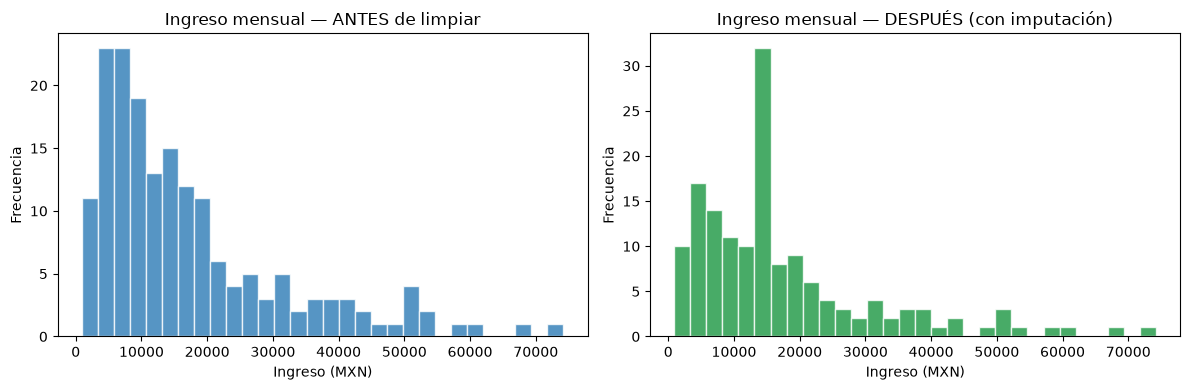


⚠️  Nota: La imputación con mediana no cambia visiblemente la distribución
   porque el 12.5% de datos faltantes es manejable. Con >30% habría que reconsiderar.


In [18]:
# Visualización rápida: ¿cómo quedó la distribución de ingreso?
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df['ingreso_mensual'].dropna(), bins=30, color='#2c7bb6', edgecolor='white', alpha=0.8)
ax1.set_title('Ingreso mensual — ANTES de limpiar')
ax1.set_xlabel('Ingreso (MXN)')
ax1.set_ylabel('Frecuencia')

ax2.hist(df_clean['ingreso_mensual_imp'], bins=30, color='#1a9641', edgecolor='white', alpha=0.8)
ax2.set_title('Ingreso mensual — DESPUÉS (con imputación)')
ax2.set_xlabel('Ingreso (MXN)')
ax2.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('\n⚠️  Nota: La imputación con mediana no cambia visiblemente la distribución')
print('   porque el 12.5% de datos faltantes es manejable. Con >30% habría que reconsiderar.')

---

## Parte 6 — Guardar el dataset limpio

In [19]:
# Guardamos el dataset limpio para usarlo en sesiones posteriores
df_clean.to_csv('enigh_limpio.csv', index=False)
print('Dataset guardado como enigh_limpio.csv')
print(f'{len(df_clean)} observaciones × {len(df_clean.columns)} variables')
print()
print('Columnas disponibles para el próximo análisis:')
for col in df_clean.columns:
    print(f'- {col}: {df_clean[col].dtype}')

Dataset guardado como enigh_limpio.csv
150 observaciones × 11 variables

Columnas disponibles para el próximo análisis:
- folio_hogar: int64
- estado: category
- num_integrantes: float64
- ingreso_mensual: float64
- edad_jefe_hogar: float64
- escolaridad_jefe: category
- acceso_internet: Int64
- gasto_alimentacion: float64
- vivienda_propia: category
- ingreso_mensual_imp: float64
- ingreso_faltante: int64


---

## Resumen de lo aprendido

- ✅ **Diagnóstico sistemático**: `dtypes`, `isnull().sum()`, `duplicated()`, `value_counts()`, `describe()`
- ✅ **Estandarización de texto**: `.str.title()`, `.replace()`, `.strip()`
- ✅ **Valores imposibles**: identificar con rangos lógicos, reemplazar con `np.nan`
- ✅ **Imputación**: mediana para numéricas, categoría especial para categóricas, indicador de faltante
- ✅ **Tipos correctos**: `astype('category')`, `pd.to_numeric(errors='coerce')`, `Int64`
- ✅ **Preservar el raw**: siempre trabajar sobre `df.copy()`

**Próxima sesión:** Con los datos limpios, arrancamos análisis exploratorio de una variable — distribuciones, medidas de tendencia central y dispersión.